1.Environment setup & imports

In [3]:
%pip install shap xgboost lightgbm imbalanced-learn scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install matplotlib seaborn scorecardpy mlflow fastapi uvicorn joblib pandera

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import warnings, os, json
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [6]:
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import OneHotEncoder, StandardScaler
from sklearn.impute             import SimpleImputer
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics           import (
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, brier_score_loss
)
from sklearn.calibration       import calibration_curve, CalibratedClassifierCV

from imblearn.over_sampling    import SMOTE
from imblearn.pipeline         import Pipeline as ImbPipeline

import xgboost  as xgb
import lightgbm as lgb
import shap


In [7]:
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

print("\u2705 All libraries loaded successfully")

✅ All libraries loaded successfully


2.Data Loading & Scheme validation

In [8]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# Load data
df_raw = pd.read_csv("credit_risk_dataset.csv")
print(f"Raw shape: {df_raw.shape}")
df_raw.head()

Raw shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [10]:
schema = DataFrameSchema({
    "person_age":               Column(float, Check.in_range(18, 100),   nullable=True),
    "person_income":            Column(float, Check.greater_than(0),      nullable=True),
    "person_emp_length":        Column(float, Check.greater_than_or_equal_to(0), nullable=True),
    "loan_amnt":                Column(float, Check.greater_than(0)),
    "loan_int_rate":            Column(float, Check.in_range(1, 60),      nullable=True),
    "loan_percent_income":      Column(float, Check.in_range(0, 1)),
    "cb_person_cred_hist_length": Column(float, Check.greater_than_or_equal_to(0)),
    "loan_status":              Column(int,   Check.isin([0, 1])),
    "loan_grade":               Column(str,   Check.isin(list("ABCDEFG"))),
    "person_home_ownership":    Column(str,   Check.isin(["RENT","OWN","MORTGAGE","OTHER"])),
    "cb_person_default_on_file":Column(str,   Check.isin(["Y","N"])),
}, coerce=True)

try:
    schema.validate(df_raw, lazy=True)
    print("\u2705 Schema validation passed")
except pa.errors.SchemaErrors as e:
    print(f"\u26A0\uFE0F  Schema issues found (non-fatal):\n{e.failure_cases.head(10)}")

⚠️  Schema issues found (non-fatal):
  schema_context      column              check  check_number  failure_case  \
0         Column  person_age  in_range(18, 100)             0         144.0   
1         Column  person_age  in_range(18, 100)             0         144.0   
2         Column  person_age  in_range(18, 100)             0         123.0   
3         Column  person_age  in_range(18, 100)             0         123.0   
4         Column  person_age  in_range(18, 100)             0         144.0   

   index  
0     81  
1    183  
2    575  
3    747  
4  32297  


EDA

In [11]:
df = df_raw.copy()

# Basic stats 
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df["loan_status"].value_counts(normalize=True).rename({0:"Paid",1:"Default"}).map("{:.1%}".format))
print(f"\nDefault rate: {df['loan_status'].mean():.2%}")

Shape: (32581, 12)

Target distribution:
loan_status
Paid       78.2%
Default    21.8%
Name: proportion, dtype: object

Default rate: 21.82%


In [12]:
# Missing value summary
missing = (df.isnull().sum()
             .to_frame("count")
             .assign(pct=lambda x: x["count"]/len(df)*100)
             .query("count > 0")
             .sort_values("pct", ascending=False))
print(missing.to_string())


                   count       pct
loan_int_rate       3116  9.563856
person_emp_length    895  2.747000


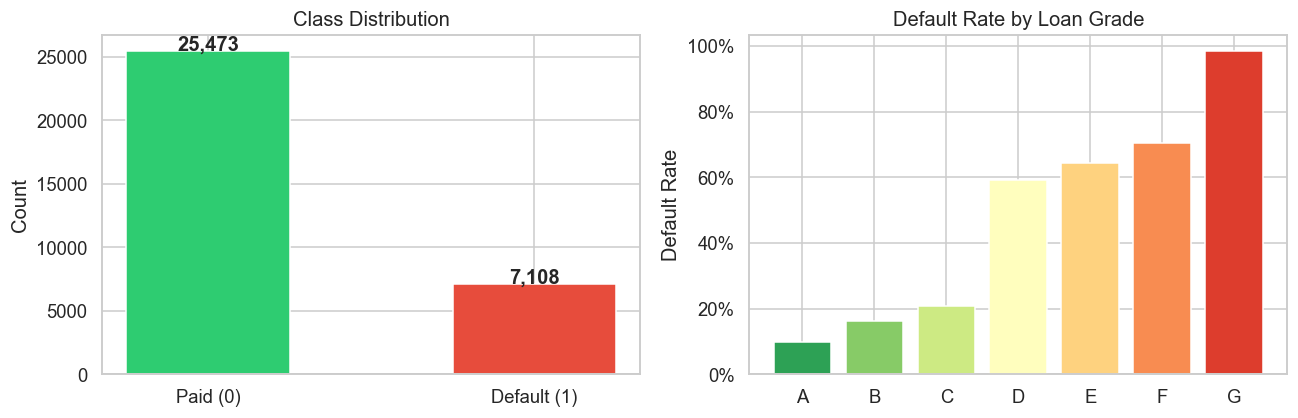

In [14]:
# Target distribution plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["loan_status"].value_counts()
axes[0].bar(["Paid (0)", "Default (1)"], counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

# Default rate by loan grade
grade_default = df.groupby("loan_grade")["loan_status"].mean().sort_index()
axes[1].bar(grade_default.index, grade_default.values,
            color=sns.color_palette("RdYlGn_r", len(grade_default)), edgecolor="white")
axes[1].set_title("Default Rate by Loan Grade")
axes[1].set_ylabel("Default Rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()


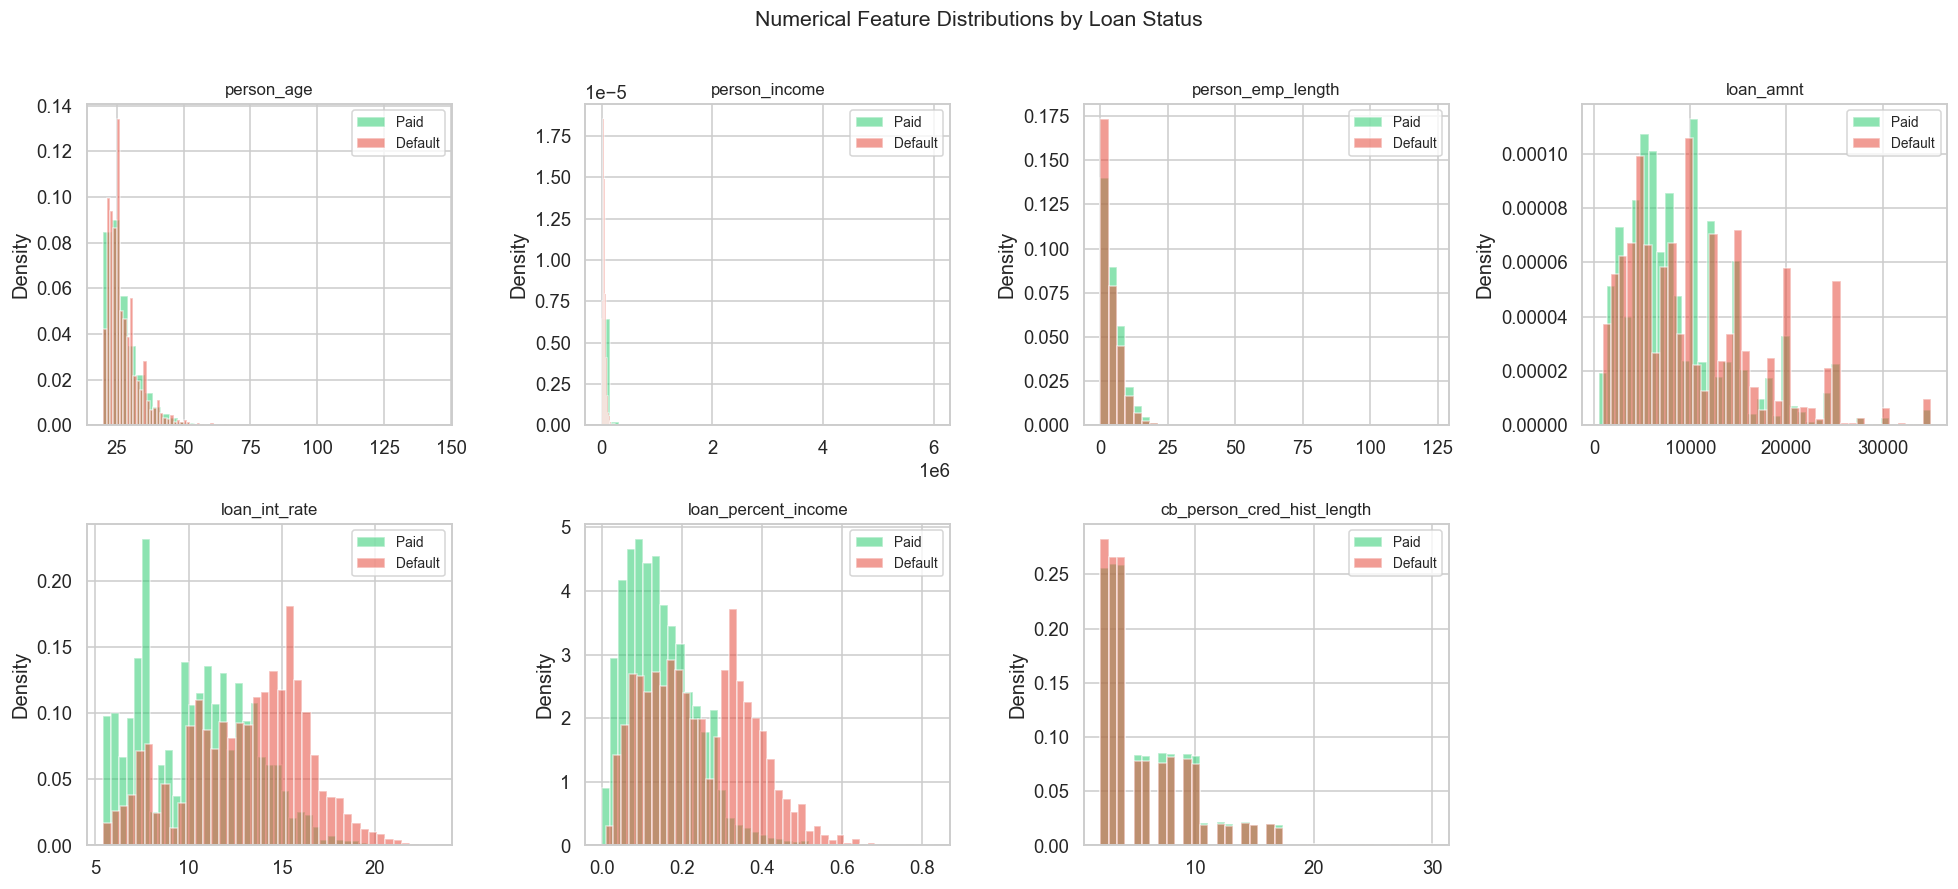

In [15]:
# Numerical feature distributions coloured by target 
num_features = ["person_age","person_income","person_emp_length",
                "loan_amnt","loan_int_rate","loan_percent_income",
                "cb_person_cred_hist_length"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for label, colour in zip([0, 1], ["#2ecc71", "#e74c3c"]):
        axes[i].hist(df.loc[df["loan_status"]==label, col].dropna(),
                     bins=40, alpha=0.55, color=colour,
                     label="Paid" if label==0 else "Default", density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle("Numerical Feature Distributions by Loan Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


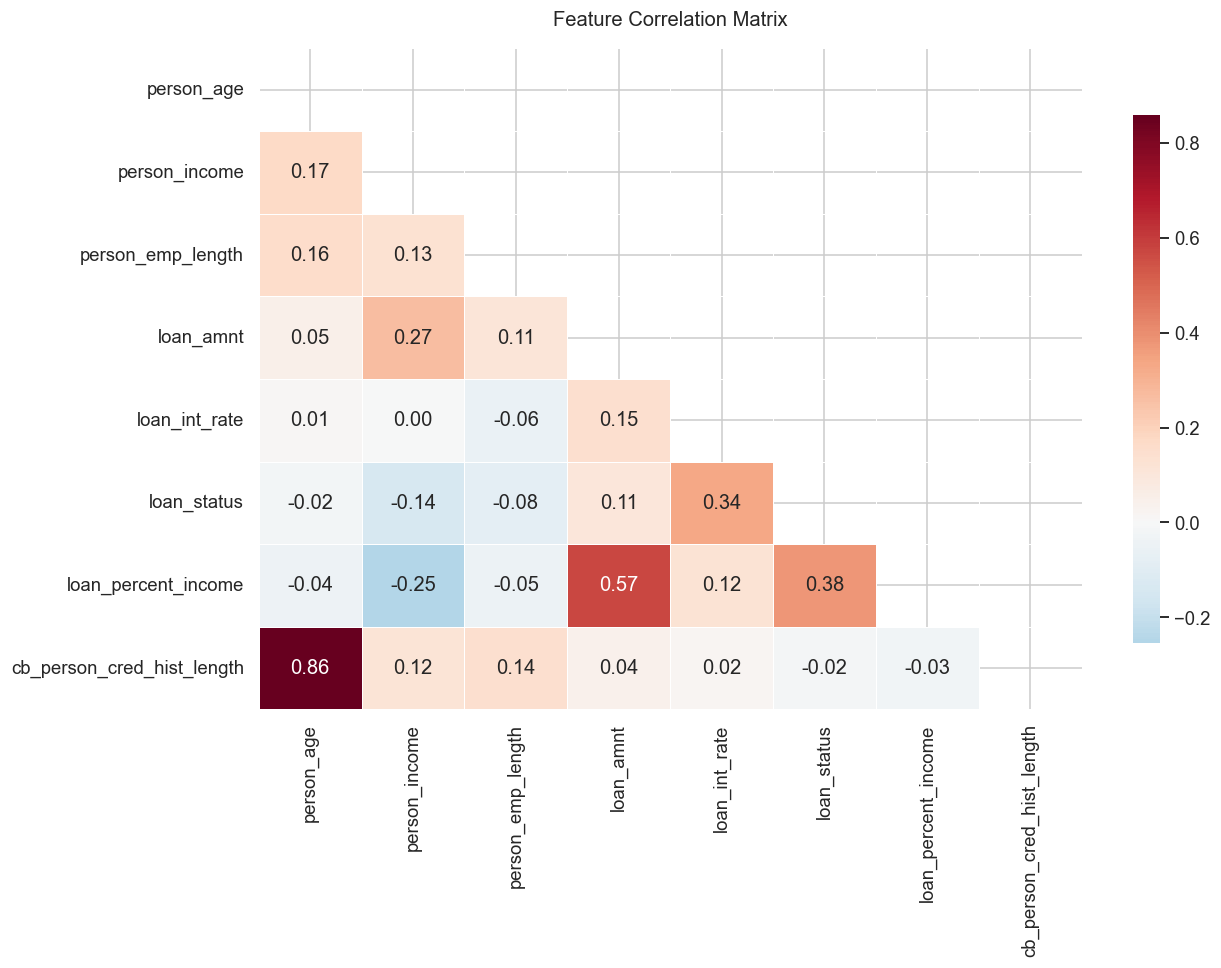


Top correlations with loan_status:
loan_percent_income           0.379366
loan_int_rate                 0.335133
person_income                -0.144449
loan_amnt                     0.105376
person_emp_length            -0.082489
person_age                   -0.021629
cb_person_cred_hist_length   -0.015529
Name: loan_status, dtype: float64


In [16]:
# Correlation heatmap 
num_df = df.select_dtypes(include=["int64","float64"])
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", pad=15)
plt.tight_layout()
plt.show()

print("\nTop correlations with loan_status:")
print(corr["loan_status"].drop("loan_status").sort_values(key=abs, ascending=False))


3.Data cleaning & Feature Engineering

In [17]:
df = df_raw.copy()

# Deduplication 
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# Business-rule validation 
invalid = pd.Series(False, index=df.index)
invalid |= (df["person_age"]   < 18) | (df["person_age"]   > 100)
invalid |= df["person_income"] <= 0
invalid |= df["loan_amnt"]     <= 0
invalid |= df["loan_amnt"]     > 10 * df["person_income"]          # extreme DTI
if "loan_int_rate" in df.columns:
    invalid |= df["loan_int_rate"].notna() & (df["loan_int_rate"] > 60)
print(f"Invalid rows flagged: {invalid.sum()} ({invalid.mean():.2%}) → removed")
df = df[~invalid].reset_index(drop=True)

# Missing-value flags (preserve signal before imputation)
for col in ["person_emp_length", "loan_int_rate"]:
    df[f"{col}_missing"] = df[col].isnull().astype(int)

print(f"\nFinal clean shape: {df.shape}")

Duplicates removed: 165
Invalid rows flagged: 5 (0.02%) → removed

Final clean shape: (32411, 14)


In [18]:
# Feature engineering

# Debt-to-income ratio (loan amount / annual income)
df["dti_ratio"] = df["loan_amnt"] / (df["person_income"] + 1)

# Income tier (log-transform to compress skew)
df["log_income"] = np.log1p(df["person_income"])

# Loan-to-credit-history ratio
df["loan_per_hist_year"] = df["loan_amnt"] / (df["cb_person_cred_hist_length"] + 1)

# Age-employment ratio (stability indicator)
df["age_emp_ratio"] = df["person_emp_length"] / (df["person_age"] + 1)

# Grade ordinal score (A=7 ... G=1)
grade_score_map = {"A":7,"B":6,"C":5,"D":4,"E":3,"F":2,"G":1}
df["grade_score"] = df["loan_grade"].map(grade_score_map)

# Risk category bucketing
df["loan_risk_tier"] = df["loan_grade"].map(
    {"A":"low","B":"low","C":"medium","D":"medium","E":"high","F":"high","G":"high"})

# Prior default flag
df["prior_default"] = (df["cb_person_default_on_file"] == "Y").astype(int)

print("Engineered features added. New shape:", df.shape)
df[["dti_ratio","log_income","loan_per_hist_year","age_emp_ratio","grade_score","prior_default"]].describe()

Engineered features added. New shape: (32411, 21)


,dti_ratio,log_income,loan_per_hist_year,age_emp_ratio,grade_score,prior_default
count,32411.000000,32411.000000,32411.000000,31524.000000,32411.000000,32411.000000
mean,0.170603,10.925404,1819.607074,0.168055,5.779519,0.176792
std,0.107073,0.565139,1530.161656,0.137213,1.167365,0.381498
min,0.000789,8.294300,33.333333,0.000000,1.000000,0.000000
25%,0.089731,10.558439,736.038961,0.062500,5.000000,0.000000
50%,0.148145,10.915107,1388.888889,0.139535,6.000000,0.000000
75%,0.229157,11.279744,2425.000000,0.260870,7.000000,0.000000
max,0.829959,14.528355,11666.666667,5.590909,7.000000,1.000000


4.Pre-Processing Pipeline

In [19]:
TARGET = "loan_status"

# Feature lists
NUM_FEATURES = [
    "person_age", "log_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "dti_ratio", "loan_per_hist_year", "age_emp_ratio", "grade_score",
    "person_emp_length_missing", "loan_int_rate_missing", "prior_default"
]

CAT_FEATURES = ["person_home_ownership", "loan_intent", "loan_risk_tier"]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]

print(f"Features: {len(ALL_FEATURES)} ({len(NUM_FEATURES)} numeric, {len(CAT_FEATURES)} categorical)")
print(f"Target balance: {y.mean():.2%} default rate")

# ── Stratified train/test split (preserves class ratio) ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

Features: 17 (14 numeric, 3 categorical)
Target balance: 21.87% default rate

Train: (25928, 17)  |  Test: (6483, 17)
Train default rate: 21.87%  |  Test: 21.87%


In [20]:
# Build sklearn ColumnTransformer (all preprocessing inside pipeline)
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, NUM_FEATURES),
    ("cat", cat_transformer, CAT_FEATURES),
], remainder="drop")

print("\u2705 Preprocessing pipeline defined (no data leakage — fit only on train)")

✅ Preprocessing pipeline defined (no data leakage — fit only on train)


5.Model Training & Cross Validation

In [22]:
# Define all models inside ImbPipeline (SMOTE applied only to train folds)
def make_pipeline(classifier):
    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote",         SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("classifier",    classifier),
    ])

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced",
                           random_state=RANDOM_STATE, solver="lbfgs")),

    "Decision Tree":        make_pipeline(
        DecisionTreeClassifier(max_depth=7, min_samples_leaf=50,
                                class_weight="balanced", random_state=RANDOM_STATE)),

    "Random Forest":        make_pipeline(
        RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                                class_weight="balanced", n_jobs=-1,
                                random_state=RANDOM_STATE)),

    "Gradient Boosting":    make_pipeline(
        GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                    max_depth=5, subsample=0.8,
                                    random_state=RANDOM_STATE)),

    "XGBoost":              make_pipeline(
        xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                            use_label_encoder=False, eval_metric="auc",
                            random_state=RANDOM_STATE, n_jobs=-1)),

    "LightGBM":             make_pipeline(
        lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                            class_weight="balanced", random_state=RANDOM_STATE,
                            n_jobs=-1, verbose=-1)),
}

print(f"\u2705 {len(models)} model pipelines defined")

✅ 6 model pipelines defined


In [23]:
# 5-fold stratified cross-validation (AUC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print(f"{'Model':<25} {'Mean AUC':>10} {'Std AUC':>10}")
print("-" * 47)

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")

Model                       Mean AUC    Std AUC
-----------------------------------------------
Logistic Regression           0.8736     0.0046
Decision Tree                 0.9057     0.0023
Random Forest                 0.9261     0.0019
Gradient Boosting             0.9405     0.0027
XGBoost                       0.9419     0.0032
LightGBM                      0.9423     0.0023


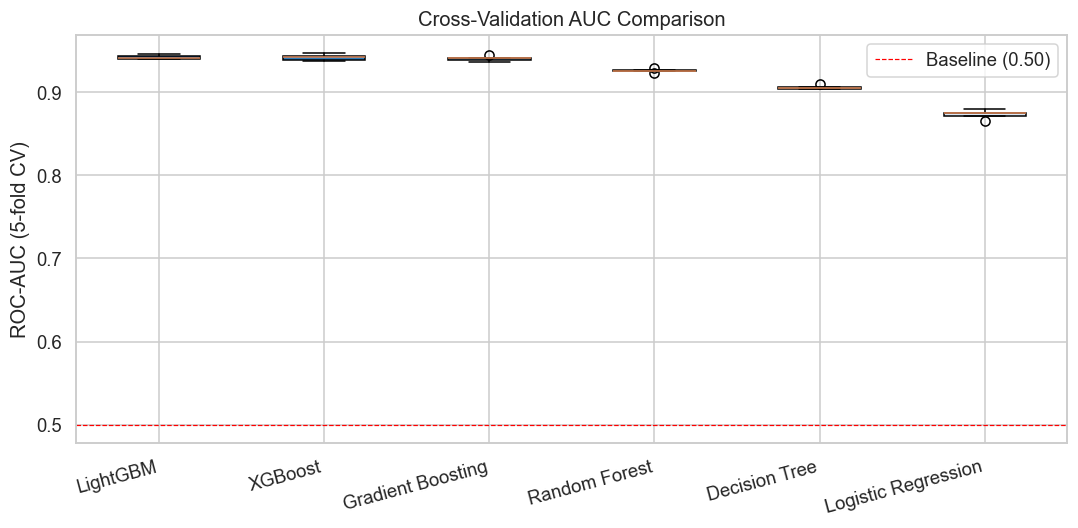

In [24]:
# CV results box plot
fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(cv_results, key=lambda k: cv_results[k].mean(), reverse=True)
data  = [cv_results[k] for k in order]

bp = ax.boxplot(data, labels=order, patch_artist=True, notch=False)
colors = sns.color_palette("Blues_r", len(order))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Cross-Validation AUC Comparison")
ax.set_xticklabels(order, rotation=15, ha="right")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Baseline (0.50)")
ax.legend()
plt.tight_layout()
plt.show()

6.Final Model training & Evaluation

In [25]:
# Train all models on full train set & evaluate on held-out test 
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = pipe.predict(X_test)
    results[name] = {"pipeline": pipe, "proba": proba, "pred": pred}

print("\u2705 All models trained on train set and scored on test set")


✅ All models trained on train set and scored on test set


In [26]:
# KS Statistic  
def ks_statistic(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return round(max(tpr - fpr), 4)

def gini_coefficient(y_true, y_score):
    return round(2 * roc_auc_score(y_true, y_score) - 1, 4)

# Full metrics table 
rows = []
for name, r in results.items():
    auc  = roc_auc_score(y_test, r["proba"])
    ks   = ks_statistic(y_test, r["proba"])
    gini = gini_coefficient(y_test, r["proba"])
    ap   = average_precision_score(y_test, r["proba"])
    brier= brier_score_loss(y_test, r["proba"])
    rep  = classification_report(y_test, r["pred"], output_dict=True)
    rows.append({
        "Model": name,
        "ROC-AUC": round(auc, 4),
        "KS Statistic": ks,
        "Gini": gini,
        "Avg Precision": round(ap, 4),
        "Brier Score↓": round(brier, 4),
        "F1-Default": round(rep["1"]["f1-score"], 4),
        "Recall-Default": round(rep["1"]["recall"], 4),
        "Precision-Default": round(rep["1"]["precision"], 4),
    })

metrics_df = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)
print(metrics_df.to_string())


                     ROC-AUC  KS Statistic    Gini  Avg Precision  Brier Score↓  F1-Default  Recall-Default  Precision-Default
Model                                                                                                                         
XGBoost               0.9393        0.7311  0.8787         0.8913        0.0815      0.7736          0.7990             0.7498
LightGBM              0.9379        0.7364  0.8758         0.8912        0.0551      0.8358          0.7306             0.9764
Gradient Boosting     0.9375        0.7270  0.8750         0.8890        0.0566      0.8317          0.7299             0.9664
Random Forest         0.9205        0.7144  0.8410         0.8700        0.0752      0.8083          0.7285             0.9077
Decision Tree         0.9075        0.6975  0.8150         0.8424        0.0728      0.8099          0.7031             0.9550
Logistic Regression   0.8723        0.5955  0.7447         0.7200        0.1399      0.6321          0.7870    

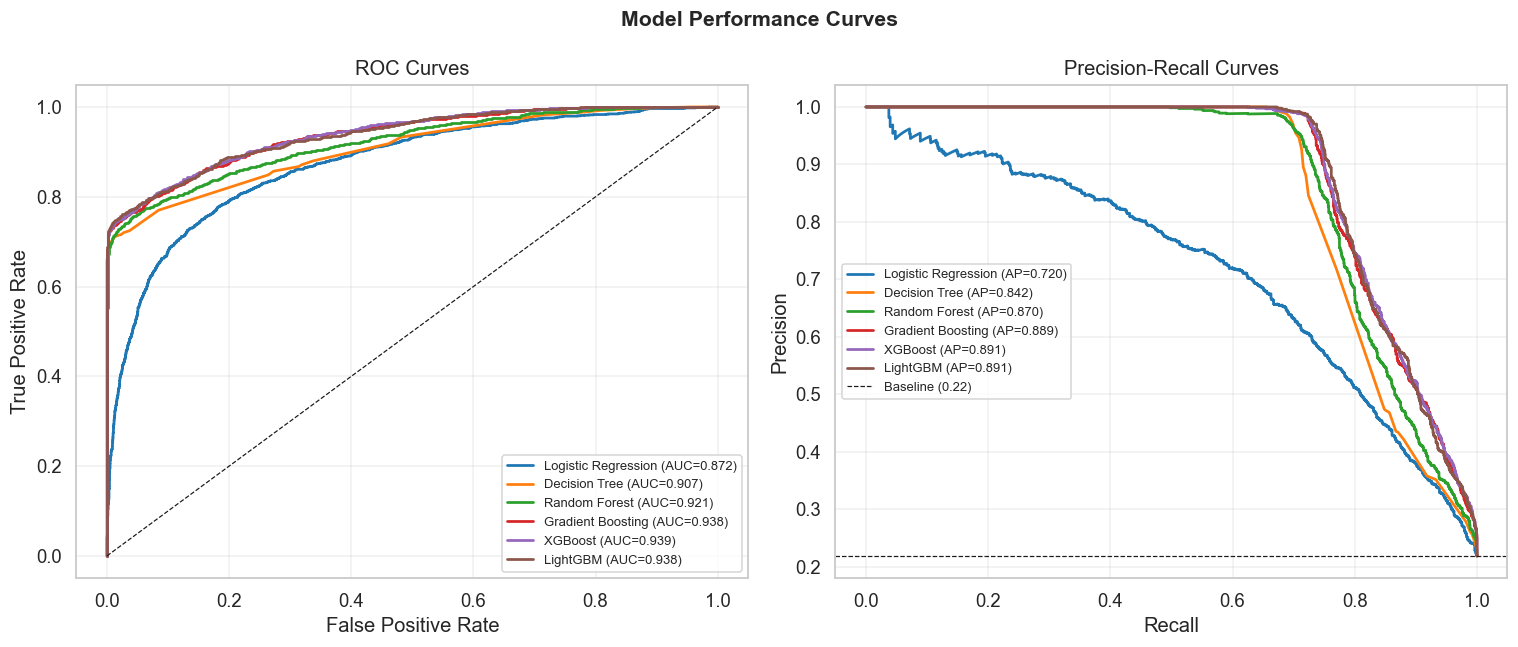

In [27]:
# ROC curves — all models 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = sns.color_palette("tab10", len(results))

# ROC
for (name, r), col in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    auc = roc_auc_score(y_test, r["proba"])
    axes[0].plot(fpr, tpr, color=col, lw=1.8, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0,1],[0,1],"k--",lw=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=8.5); axes[0].grid(True, alpha=0.3)

# Precision-Recall
for (name, r), col in zip(results.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    ap = average_precision_score(y_test, r["proba"])
    axes[1].plot(rec, prec, color=col, lw=1.8, label=f"{name} (AP={ap:.3f})")
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", linestyle="--", lw=0.8, label=f"Baseline ({baseline:.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=8.5); axes[1].grid(True, alpha=0.3)

plt.suptitle("Model Performance Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [28]:
# Best model selection 
best_name = metrics_df["ROC-AUC"].idxmax()
best_pipe  = results[best_name]["pipeline"]
best_proba = results[best_name]["proba"]
best_pred  = results[best_name]["pred"]

print(f"\U0001F3C6  Best model: {best_name}")
print(f"   ROC-AUC:     {roc_auc_score(y_test, best_proba):.4f}")
print(f"   KS:          {ks_statistic(y_test, best_proba):.4f}")
print(f"   Gini:        {gini_coefficient(y_test, best_proba):.4f}")
print()
print(classification_report(y_test, best_pred, target_names=["Paid","Default"]))


🏆  Best model: XGBoost
   ROC-AUC:     0.9393
   KS:          0.7311
   Gini:        0.8787

              precision    recall  f1-score   support

        Paid       0.94      0.93      0.93      5065
     Default       0.75      0.80      0.77      1418

    accuracy                           0.90      6483
   macro avg       0.85      0.86      0.85      6483
weighted avg       0.90      0.90      0.90      6483



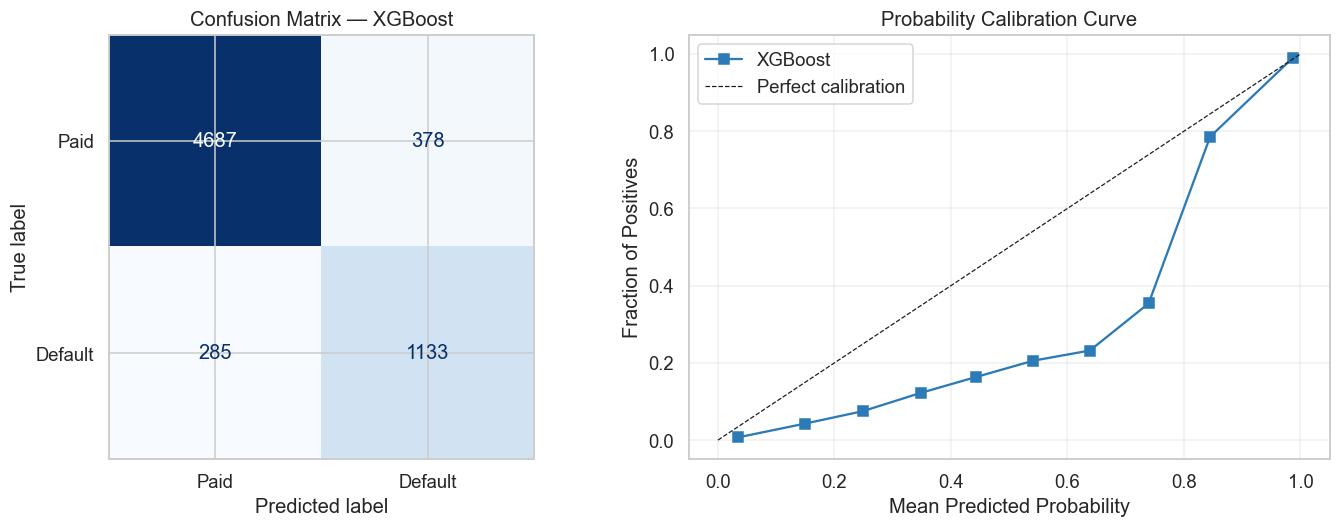

In [29]:
# Confusion matrix + calibration curve 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Paid","Default"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {best_name}")

# Calibration
fraction_pos, mean_pred = calibration_curve(y_test, best_proba, n_bins=10)
axes[1].plot(mean_pred, fraction_pos, "s-", label=f"{best_name}", color="#2c7bb6")
axes[1].plot([0,1],[0,1],"k--", lw=0.8, label="Perfect calibration")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Fraction of Positives")
axes[1].set_title("Probability Calibration Curve")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

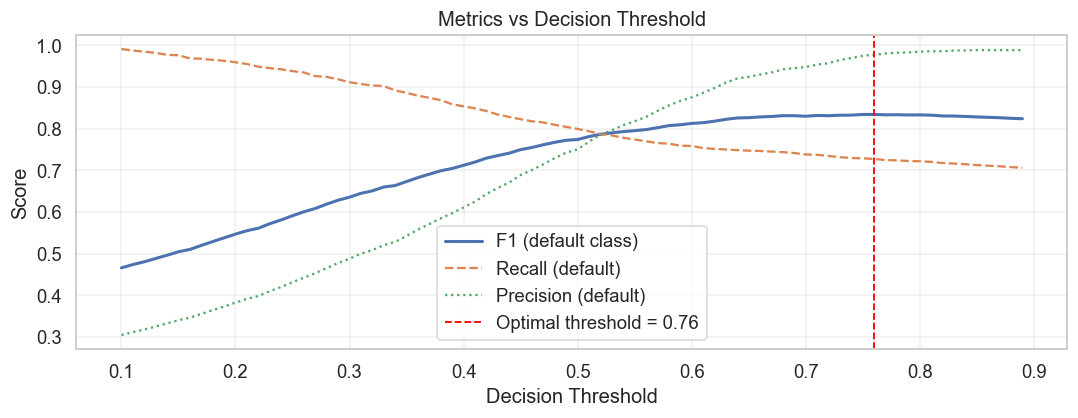


✅ Optimal threshold (max F1 for default class): 0.76
              precision    recall  f1-score   support

        Paid       0.93      1.00      0.96      5065
     Default       0.98      0.73      0.83      1418

    accuracy                           0.94      6483
   macro avg       0.95      0.86      0.90      6483
weighted avg       0.94      0.94      0.93      6483



In [30]:
# Threshold analysis: find optimal cut-off 
thresholds = np.arange(0.1, 0.9, 0.01)
f1s, recs, pres = [], [], []

for t in thresholds:
    pred_t = (best_proba >= t).astype(int)
    rep = classification_report(y_test, pred_t, output_dict=True, zero_division=0)
    f1s.append(rep["1"]["f1-score"])
    recs.append(rep["1"]["recall"])
    pres.append(rep["1"]["precision"])

optimal_idx = np.argmax(f1s)
OPTIMAL_THRESHOLD = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1s,  label="F1 (default class)",  lw=2)
ax.plot(thresholds, recs, label="Recall (default)",     lw=1.5, linestyle="--")
ax.plot(thresholds, pres, label="Precision (default)",  lw=1.5, linestyle=":")
ax.axvline(OPTIMAL_THRESHOLD, color="red", linestyle="--", lw=1.2,
           label=f"Optimal threshold = {OPTIMAL_THRESHOLD:.2f}")
ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs Decision Threshold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n\u2705 Optimal threshold (max F1 for default class): {OPTIMAL_THRESHOLD:.2f}")
print(classification_report(y_test, (best_proba >= OPTIMAL_THRESHOLD).astype(int),
                              target_names=["Paid","Default"]))


7.Model Explainability with SHAP

In [31]:
# Extract the raw classifier from the pipeline 
clf = best_pipe.named_steps["classifier"]

# Get transformed feature names
ohe_features = (best_pipe.named_steps["preprocessor"]
                .named_transformers_["cat"]
                .named_steps["ohe"]
                .get_feature_names_out(CAT_FEATURES).tolist())
feature_names = NUM_FEATURES + ohe_features

# Transform test data through preprocessor only (post-SMOTE not needed for inference)
X_test_proc = best_pipe.named_steps["preprocessor"].transform(X_test)

# SHAP explainer 
if hasattr(clf, "get_booster") or isinstance(clf, lgb.LGBMClassifier):
    explainer = shap.TreeExplainer(clf)
else:
    explainer = shap.Explainer(clf, X_test_proc[:200])

shap_values = explainer(X_test_proc[:500])
print(f"\u2705 SHAP values computed. Shape: {shap_values.values.shape}")


✅ SHAP values computed. Shape: (500, 27)


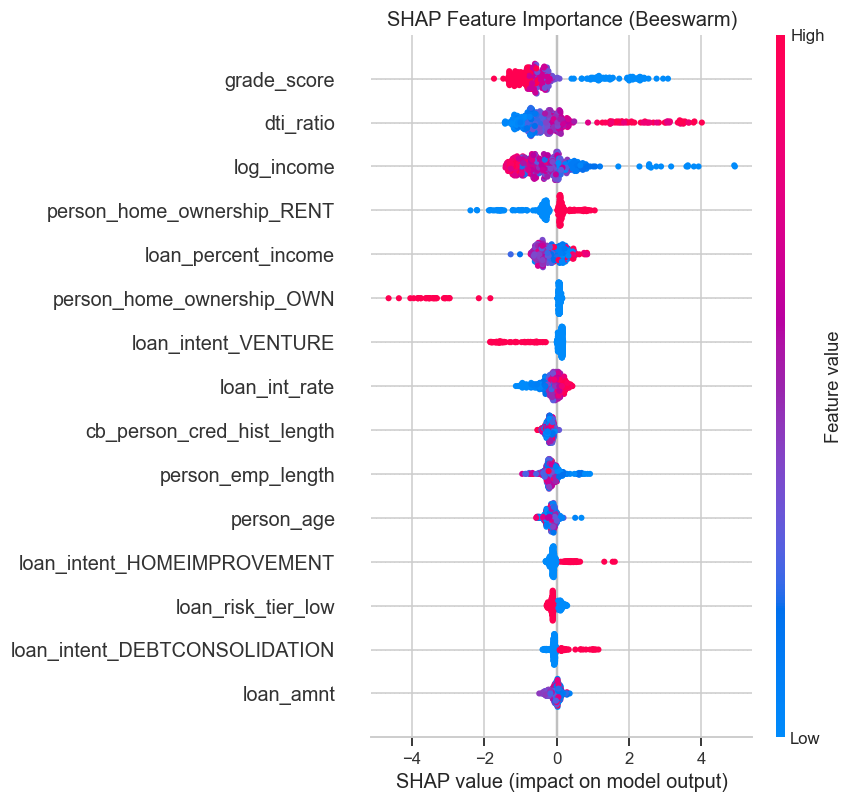

In [32]:
# SHAP summary (beeswarm) 
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values.values if hasattr(shap_values, "values") else shap_values,
                  X_test_proc[:500], feature_names=feature_names,
                  max_display=15, show=False)
plt.title("SHAP Feature Importance (Beeswarm)")
plt.tight_layout(); plt.show()


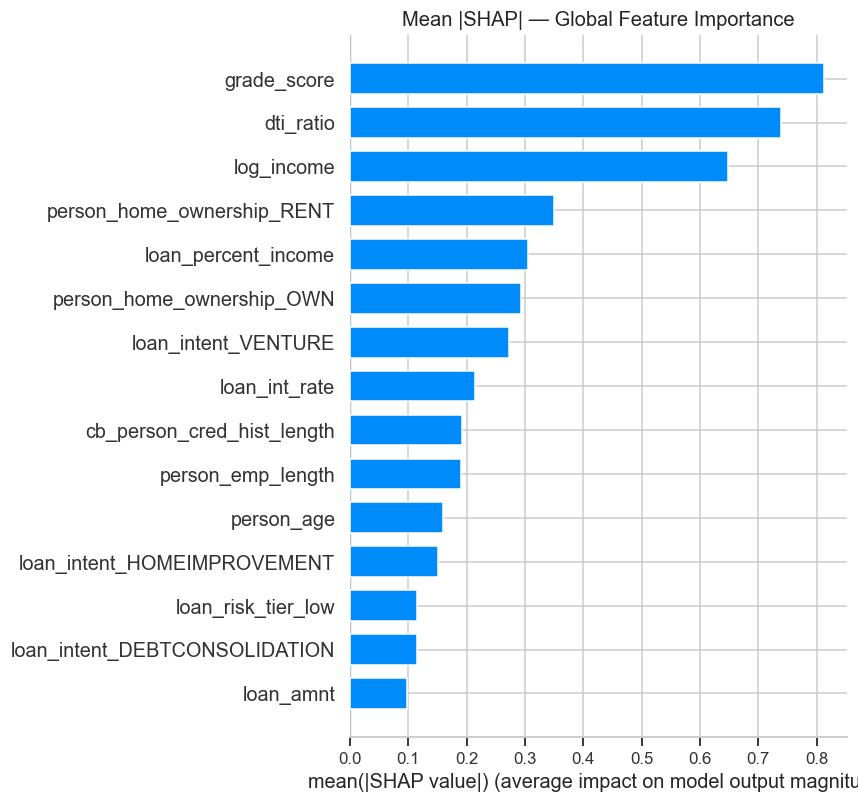

In [33]:
# SHAP bar (mean absolute impact) 
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values.values if hasattr(shap_values, "values") else shap_values,
                  X_test_proc[:500], feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("Mean |SHAP| — Global Feature Importance")
plt.tight_layout(); plt.show()


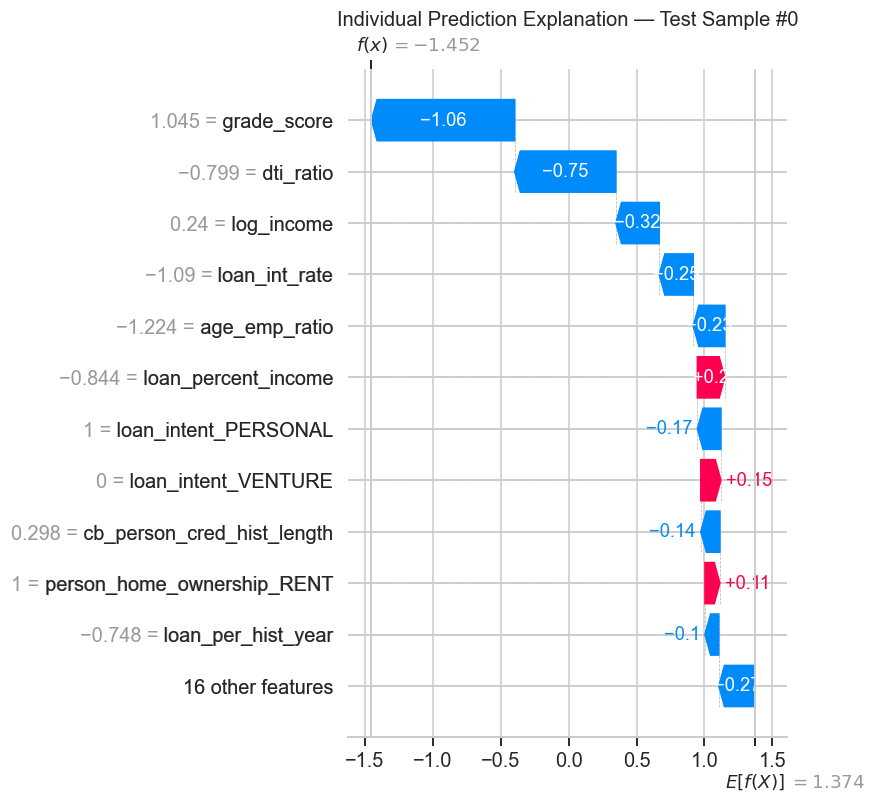

Predicted default probability: 18.96%
Actual outcome: Paid


In [34]:
# SHAP waterfall for a single prediction (applicant-level explanation)
idx = 0   # change to any test row index
sv = shap_values[idx]

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(
    values        = sv.values if hasattr(sv, "values") else sv,
    base_values   = explainer.expected_value if np.isscalar(explainer.expected_value)
                    else explainer.expected_value[1],
    data          = X_test_proc[idx],
    feature_names = feature_names
), show=False, max_display=12)
plt.title(f"Individual Prediction Explanation — Test Sample #{idx}")
plt.tight_layout(); plt.show()
print(f"Predicted default probability: {best_proba[idx]:.2%}")
print(f"Actual outcome: {'Default' if y_test.iloc[idx]==1 else 'Paid'}")

8.Credit Scorecard

In [35]:
# Build a points-based scorecard from probabilities 
# Standard scorecard: Score = Offset + Factor * log(odds)
# Calibrated so score of 600 ↔ odds 50:1 (non-default), 20 pts = double the odds

def prob_to_score(prob, base_score=600, base_odds=50, pdo=20):
    """Convert default probability to credit score (higher = safer)."""
    odds = (1 - prob) / (prob + 1e-9)
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    return np.round(offset + factor * np.log(np.maximum(odds, 1e-9))).astype(int)

# Score the test set
test_scores = prob_to_score(best_proba)
print(f"Score range: {test_scores.min()} — {test_scores.max()}")
print(f"Mean score:  {test_scores.mean():.0f}")


Score range: 212 — 726
Mean score:  511


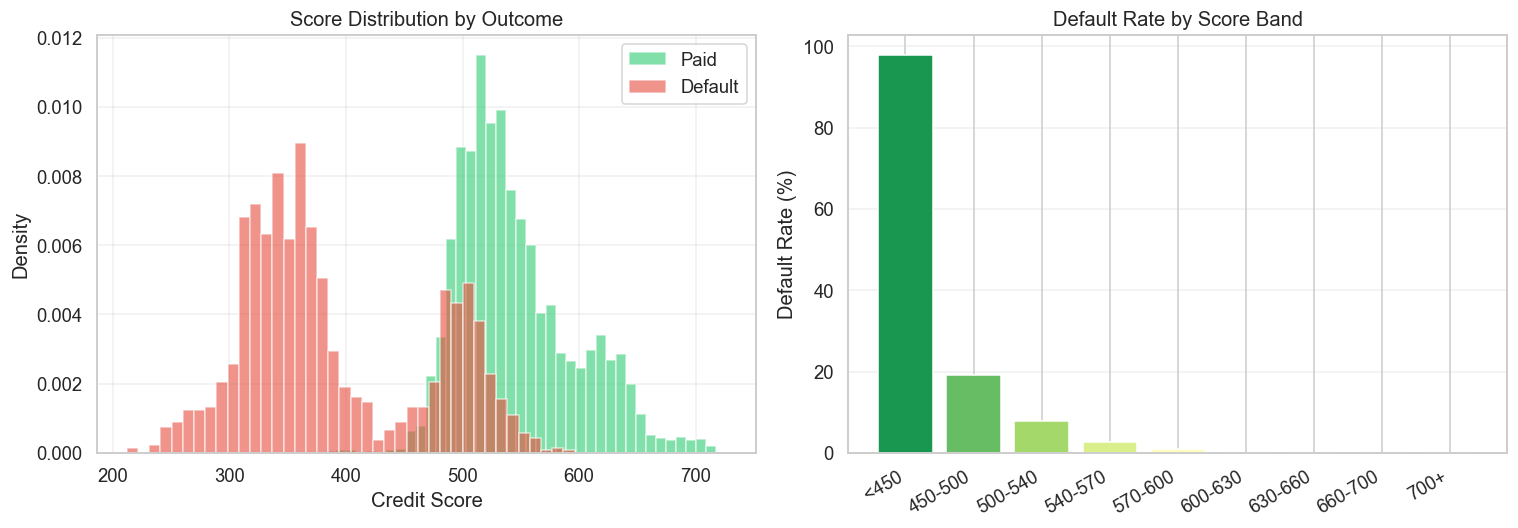

         default_rate     n
band                       
<450         0.979614   932
450-500      0.191406  1024
500-540      0.077209  2150
540-570      0.027719   938
570-600      0.008230   486
600-630      0.000000   449
630-660      0.000000   282
660-700      0.000000    83
700+         0.000000    26


In [36]:
# Score distribution by actual outcome 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, colour, name in zip([0, 1], ["#2ecc71","#e74c3c"], ["Paid","Default"]):
    mask = y_test == label
    axes[0].hist(test_scores[mask], bins=40, alpha=0.6,
                 color=colour, label=name, density=True)
axes[0].set_xlabel("Credit Score"); axes[0].set_ylabel("Density")
axes[0].set_title("Score Distribution by Outcome")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Default rate by score band
bands = pd.cut(test_scores,
               bins=[300,450,500,540,570,600,630,660,700,850],
               labels=["<450","450-500","500-540","540-570","570-600",
                        "600-630","630-660","660-700","700+"])
score_df = pd.DataFrame({"band": bands, "default": y_test.values})
band_summary = (score_df.groupby("band", observed=False)["default"]
                  .agg(["mean","count"])
                  .rename(columns={"mean":"default_rate","count":"n"}))

axes[1].bar(range(len(band_summary)), band_summary["default_rate"]*100,
            color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(band_summary))),
            edgecolor="white")
axes[1].set_xticks(range(len(band_summary)))
axes[1].set_xticklabels(band_summary.index, rotation=30, ha="right")
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_title("Default Rate by Score Band")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()
print(band_summary.to_string())


9.Model Calibration

In [37]:
# Isotonic calibration (improve probability reliability) 
calibrated_model = CalibratedClassifierCV(best_pipe, cv=5, method="isotonic")
calibrated_model.fit(X_train, y_train)
cal_proba = calibrated_model.predict_proba(X_test)[:, 1]

print("Before calibration — Brier score:", round(brier_score_loss(y_test, best_proba), 4))
print("After  calibration — Brier score:", round(brier_score_loss(y_test, cal_proba), 4))
print("Before calibration — AUC:", round(roc_auc_score(y_test, best_proba), 4))
print("After  calibration — AUC:", round(roc_auc_score(y_test, cal_proba), 4))

Before calibration — Brier score: 0.0815
After  calibration — Brier score: 0.0543
Before calibration — AUC: 0.9393
After  calibration — AUC: 0.9393


In [38]:
# Save final artefacts
import os
os.makedirs("model_artifacts", exist_ok=True)

joblib.dump(calibrated_model,  "model_artifacts/credit_risk_model.pkl")
joblib.dump(OPTIMAL_THRESHOLD, "model_artifacts/optimal_threshold.pkl")

# Save feature schema for validation at serving time
feature_schema = {
    "num_features": NUM_FEATURES,
    "cat_features": CAT_FEATURES,
    "target": TARGET,
    "optimal_threshold": float(OPTIMAL_THRESHOLD),
    "model_name": best_name,
    "auc_test": round(roc_auc_score(y_test, best_proba), 4),
    "ks_test":  ks_statistic(y_test, best_proba),
    "gini_test":gini_coefficient(y_test, best_proba),
}
with open("model_artifacts/model_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2)

print("\u2705 Artefacts saved:")
for f in os.listdir("model_artifacts"):
    print(f"   model_artifacts/{f}")

✅ Artefacts saved:
   model_artifacts/credit_risk_model.pkl
   model_artifacts/MODEL_CARD.md
   model_artifacts/model_schema.json
   model_artifacts/optimal_threshold.pkl


10.Model card

In [39]:
with open("model_artifacts/model_schema.json") as f:
    schema = json.load(f)

model_card = f"""
# Model Card — Credit Risk Classifier

## Model Details
| Field              | Value                       |
|--------------------|-----------------------------|
| Model type         | {schema['model_name']}      |
| Version            | 1.0.0                       |
| Training date      | {pd.Timestamp.today().date()}|
| Target variable    | {schema['target']}          |
| Decision threshold | {schema['optimal_threshold']}|

## Performance (Hold-out Test Set)
| Metric         | Value            |
|----------------|------------------|
| ROC-AUC        | {schema['auc_test']} |
| KS Statistic   | {schema['ks_test']}  |
| Gini           | {schema['gini_test']}|

## Features
**Numerical ({len(schema['num_features'])}):**  
{', '.join(schema['num_features'])}

**Categorical ({len(schema['cat_features'])}):**  
{', '.join(schema['cat_features'])}

## Intended Use
- Binary classification of loan default risk
- Supports credit underwriting decisions
- Threshold tuned to maximise F1 on the minority (default) class

## Limitations
- Trained on historical data; periodic retraining recommended (suggest every 6 months)
- Monitor for demographic drift and fairness metrics in production
- Not a substitute for full underwriting review on borderline cases (score 540-600)

## Explainability
- SHAP TreeExplainer used for global and per-applicant explanations
- All individual decisions can be explained via the /predict endpoint

## Monitoring
- Track PSI (Population Stability Index) on input features monthly
- Alert if AUC on live labelled data drops below 0.75
"""

with open("model_artifacts/MODEL_CARD.md", "w") as f:
    f.write(model_card)

print(model_card)



# Model Card — Credit Risk Classifier

## Model Details
| Field              | Value                       |
|--------------------|-----------------------------|
| Model type         | XGBoost      |
| Version            | 1.0.0                       |
| Training date      | 2026-04-15|
| Target variable    | loan_status          |
| Decision threshold | 0.7599999999999997|

## Performance (Hold-out Test Set)
| Metric         | Value            |
|----------------|------------------|
| ROC-AUC        | 0.9393 |
| KS Statistic   | 0.7311  |
| Gini           | 0.8787|

## Features
**Numerical (14):**  
person_age, log_income, person_emp_length, loan_amnt, loan_int_rate, loan_percent_income, cb_person_cred_hist_length, dti_ratio, loan_per_hist_year, age_emp_ratio, grade_score, person_emp_length_missing, loan_int_rate_missing, prior_default

**Categorical (3):**  
person_home_ownership, loan_intent, loan_risk_tier

## Intended Use
- Binary classification of loan default risk
- Supports cr